Sat May 30th:
Initial implementation of an MLP layer, and ridge regression, as well as weights. Found that accuracy was slightly increased with MLP and ridge regression, with regular unweighted MLP being the heighest.

In [1]:
import numpy as np
import pandas as pd
import torch
import esm   
# from Bio import SeqIO
import torch
# import gc
from sklearn.manifold import TSNE
from sklearn import metrics
import matplotlib.pyplot as plt
import pickle

from sklearn.decomposition import PCA



In [2]:
# load the dataframes
train_df_mean = pd.read_csv("../processed_data/df_Atlass_nuclear_localizations_mean_pooling.csv")
train_df_max = pd.read_csv("../processed_data/df_Atlass_nuclear_localizations_max_pooling.csv")

In [3]:
# load the dataframes
train_df_mean = pd.read_csv("../processed_data/df_train_loc_mean.csv")
train_df_max = pd.read_csv("../processed_data/df_train_loc_max.csv")
test_df_mean = pd.read_csv("../processed_data/df_test_loc_mean.csv")

In [9]:
locations_test = ['Cytoplasm', 'Nucleus', 'Cell membrane',
             'Mitochondrion', 'Endoplasmic reticulum', 'Lysosome/Vacuole',
             'Golgi apparatus', 'Peroxisome']

locations = ['Membrane', 'Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane',
             'Mitochondrion', 'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole',
             'Golgi apparatus', 'Peroxisome']

#locations_nuc = ['Nucleoplasm', 'Nucleoli', 'Nuclear Bodies', 'Nuclear speckles',
#                   'Nuclear membrane', 'Fibrillar center', 'other']

# mean
y_train_df_mean = train_df_mean[locations]
balancing_weights = y_train_df_mean.shape[0]/y_train_df_mean.sum()
x_train_df_mean = train_df_mean[[c for c in train_df_mean.columns if c.startswith('emb_')]]

# test
y_test_df_mean = test_df_mean[locations_test]
x_test_df_mean = test_df_mean[[c for c in train_df_mean.columns if c.startswith('emb_')]]
y_test_df_mean = y_test_df_mean.reindex(columns=locations, fill_value=0) # to include all of the correct locations

# max
y_train_df_max = train_df_max[locations]
balancing_weights = y_train_df_max.shape[0]/y_train_df_max.sum()
x_train_df_max = train_df_max[[c for c in train_df_max.columns if c.startswith('emb_')]]

In [ ]:
print(y_train_df_mean)

In [ ]:
print(y_test_df_mean)

In [ ]:
print(y_test_df_mean)

In [10]:
# generate train/dev split
from sklearn.model_selection import train_test_split

# for mean
x_train_mean, x_dev_mean, y_train_mean, y_dev_mean = train_test_split(x_train_df_mean, y_train_df_mean, test_size=0.2, random_state=42)

# for max
x_train_max, x_dev_max, y_train_max, y_dev_max = train_test_split(x_train_df_max, y_train_df_max, test_size=0.2, random_state=42)

In [29]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# load the batches and make the model for mean
x_train_mean_tensor = torch.tensor(x_train_mean.values, dtype=torch.float32)
y_train_mean_tensor = torch.tensor(y_train_mean.values, dtype=torch.float32)
train_dataset_mean = TensorDataset(x_train_mean_tensor, y_train_mean_tensor)
train_loader_mean = DataLoader(train_dataset_mean, batch_size=64, shuffle=True)

# load the whole train set into the batches
x_train_mean_tensor_whole = torch.tensor(x_train_df_mean.values, dtype=torch.float32)
y_train_mean_tensor_whole = torch.tensor(y_train_df_mean.values, dtype=torch.float32)
train_dataset_mean_whole = TensorDataset(x_train_mean_tensor_whole, y_train_mean_tensor_whole)
train_loader_mean_whole = DataLoader(train_dataset_mean_whole, batch_size=64, shuffle=True)

# load the batches and make the model for max
x_train_max_tensor = torch.tensor(x_train_max.values, dtype=torch.float32)
y_train_max_tensor = torch.tensor(y_train_max.values, dtype=torch.float32)
train_dataset_max = TensorDataset(x_train_max_tensor, y_train_max_tensor)
train_loader_max = DataLoader(train_dataset_max, batch_size=64, shuffle=True)

# make dev tensors
x_dev_mean_tensor = torch.tensor(x_dev_mean.values, dtype=torch.float32)
y_dev_mean_tensor = torch.tensor(y_dev_mean.values, dtype=torch.float32)
x_dev_max_tensor = torch.tensor(x_dev_max.values, dtype=torch.float32)
y_dev_max_tensor = torch.tensor(y_dev_max.values, dtype=torch.float32)

# make test tensors
x_test_mean_tensor = torch.tensor(x_test_df_mean.values, dtype=torch.float32)
y_test_mean_tensor = torch.tensor(y_test_df_mean.values, dtype=torch.float32)
print(y_test_mean_tensor.shape)
print(x_test_mean_tensor.shape)

torch.Size([1716, 11])
torch.Size([1716, 1280])


In [30]:
# make the model - multilayer perceptatron

class MLP(nn.Module):
    
    def __init__(self, input_size, num_logits):
        # call to the __init__ function of the super class
        super().__init__()

        # Bookkeeping: Sacing the initialization parameters
        self.input_size = input_size
        self.num_logits = num_logits

        # Defining the model
        self.model = nn.Sequential(
            nn.Linear(self.input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.num_logits)
        )

    def forward(self, x):
        logits = self.model(x)
        return logits
    

In [31]:
import torch.optim as optim
from sklearn.metrics import (matthews_corrcoef, f1_score,
                             hamming_loss, jaccard_score)

# train the model
def train_model(model, loader, criterion, optimizer, x_dev_tensor, y_dev_tensor, num_epochs):
    # initialize the lists
    print("Training started!")
    train_loss_lst = []
    dev_loss_lst = []
    # go through the training epochs
    for epoch in range(num_epochs):
        train_loss = 0.0
        # configure the model for training
        model.train()
        for batch in loader:
            inputs, labels = batch
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)
        
        # evaluate the dev set
        model.eval()
        with torch.no_grad():
            logits_dev = model(x_dev_tensor)
            loss_dev = criterion(logits_dev, y_dev_tensor)
            dev_loss_lst.append(loss_dev.item())
        # print the progress
        #if epoch % 10 == 0 or epoch == num_epochs - 1:
            #print(f"Epoch {epoch+1}/{num_epochs}, Train Loss {train_loss:.4f}, Dev Loss {loss_dev.item():.4f}")
    print("Training Complete!")
    return train_loss_lst, dev_loss_lst

def plot_losses(train_loss_lst, dev_loss_lst, n_epochs, experiment_title):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_epochs + 1), train_loss_lst, label='train')
    plt.plot(range(1, n_epochs + 1), dev_loss_lst,   label='dev')
    plt.xlabel('Epoch')
    plt.ylabel('Avg BCE Loss')
    plt.title(f"Training vs. Dev Loss for {experiment_title}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return

def run_experiment(x_train, y_train, train_loader, x_dev, y_dev, criterion, experiment_title, num_epochs):
    model = MLP(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst, dev_loss_lst = train_model(model, train_loader, criterion, optimizer, x_dev, y_dev, num_epochs)

    # graph the losses
    #plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

# all thresholds set to 0.5
def compute_accuracy(model, X_dev, Y_dev, locations):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_dev))
        preds = (probs > 0.5).float()

    y_np = Y_dev.numpy().astype(int)
    p_np = preds.numpy().astype(int)

    # overall metrics (adapted from deeploc2 calculate_sl_metrics_fold)
    acc_exact = (np.all(p_np == y_np, axis=1)).mean()          # all 11 labels correct
    jaccard = jaccard_score(y_np, p_np, average='samples')   # intersection/union per protein
    micro_f1 = f1_score(y_np, p_np, average='micro', zero_division=0)
    macro_f1 = f1_score(y_np, p_np, average='macro', zero_division=0)

    model_accs = [acc_exact, jaccard, micro_f1, macro_f1]
    
    #print(f"Exact-match accuracy : {acc_exact:.4f}")
    #print(f"Jaccard (samples)    : {jaccard:.4f}")
    #print(f"Micro F1             : {micro_f1:.4f}")
    #print(f"Macro F1             : {macro_f1:.4f}")

    # per-class accuracy & MCC
    #print("Per-class metrics:")
    #print(f"{'Location':<25} {'Accuracy':>10} {'MCC':>10}")
    #print("-" * 47)
    class_mccs = []
    for i, loc in enumerate(locations):
        class_acc = (p_np[:, i] == y_np[:, i]).mean()
        class_mcc = matthews_corrcoef(y_np[:, i], p_np[:, i])
        class_mccs.append(class_mcc)
        #print(f"{loc:<25} {class_acc:>10.4f} {class_mcc:>10.4f}")
    return model_accs, class_mccs


In [37]:
import torch.optim as optim
from sklearn.metrics import (matthews_corrcoef, f1_score,
                             hamming_loss, jaccard_score)

# train the model with NO DEV SETS!
def train_model_wo_dev(model, loader, criterion, optimizer, num_epochs):
    # initialize the lists
    print("Training started!")
    train_loss_lst = []
    # go through the training epochs
    for epoch in range(num_epochs):
        train_loss = 0.0
        # configure the model for training
        model.train()
        for batch in loader:
            inputs, labels = batch
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)
        
    print("Training Complete!")
    return train_loss_lst

# version with no dev set needed
def run_experiment_wo_dev(x_train, y_train, train_loader, criterion, experiment_title, num_epochs):
    model = MLP(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst = train_model_wo_dev(model, train_loader, criterion, optimizer, num_epochs)

    # graph the losses
    #plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

# all thresholds set to 0.5
def compute_accuracy(model, X_dev, Y_dev, locations):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_dev))
        preds = (probs > 0.5).float()

    y_np = Y_dev.numpy().astype(int)
    p_np = preds.numpy().astype(int)

    # overall metrics (adapted from deeploc2 calculate_sl_metrics_fold)
    acc_exact = (np.all(p_np == y_np, axis=1)).mean()          # all 11 labels correct
    jaccard = jaccard_score(y_np, p_np, average='samples')   # intersection/union per protein
    micro_f1 = f1_score(y_np, p_np, average='micro', zero_division=0)
    macro_f1 = f1_score(y_np, p_np, average='macro', zero_division=0)

    model_accs = [acc_exact, jaccard, micro_f1, macro_f1]
    
    #print(f"Exact-match accuracy : {acc_exact:.4f}")
    #print(f"Jaccard (samples)    : {jaccard:.4f}")
    #print(f"Micro F1             : {micro_f1:.4f}")
    #print(f"Macro F1             : {macro_f1:.4f}")

    # per-class accuracy & MCC
    #print("Per-class metrics:")
    #print(f"{'Location':<25} {'Accuracy':>10} {'MCC':>10}")
    #print("-" * 47)
    class_mccs = []
    for i, loc in enumerate(locations):
        class_acc = (p_np[:, i] == y_np[:, i]).mean()
        class_mcc = matthews_corrcoef(y_np[:, i], p_np[:, i])
        class_mccs.append(class_mcc)
        #print(f"{loc:<25} {class_acc:>10.4f} {class_mcc:>10.4f}")
    return model_accs, class_mccs

In [33]:
# play with tuning the decision boundaries

# computes the accuracy (MCC) for a specific location given a specific cutoff and returns that accuracy
def compute_adjusted_accuracy_on_loc(model, X_dev, Y_dev, cutoff, location):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(X_dev))[:,location]
        pred = (prob > cutoff).float()

    y_np = Y_dev[:,location].numpy().astype(int)
    p_np = pred.numpy().astype(int)

    class_mcc = matthews_corrcoef(y_np, p_np)
    return class_mcc

# takes in a list of cutoffs and locations, as well as a model and the dev sets,
# and returns a dictionary of Key: location index , value: cutoff value
def compute_optimized_cutoffs(model, X_dev, Y_dev, locations):
    cutoffs = np.arange(0.01, 1.00, 0.01, dtype=float)
    cutoff_dict = {}
    for location in range(len(locations)):
        best_cutoff = 0.00
        best_mcc = 0.00
        for cutoff in cutoffs:
            this_mcc = compute_adjusted_accuracy_on_loc(model, X_dev, Y_dev, cutoff, location)
            if this_mcc > best_mcc:
                best_mcc = this_mcc
                best_cutoff = cutoff
        print(f"{locations[location]:<25}, Best Cutoff: {best_cutoff:>10.4f}, Best MCC: {best_mcc:>10.4f}")
        cutoff_dict[location] = best_cutoff
    return cutoff_dict

# same compute accuracy function but it uses the optimized cutoff for each class
def compute_accuracy_with_special_cutoffs(model, X_dev, Y_dev, locations, cutoffs_dict):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_dev))
        preds = probs
        for location in range(len(locations)):
            cutoff = cutoffs_dict[location]
            preds[:,location] = (preds[:,location] > cutoff).float()

    y_np = Y_dev.numpy().astype(int)
    p_np = preds.numpy().astype(int)

    # overall metrics (adapted from deeploc2 calculate_sl_metrics_fold)
    acc_exact = (np.all(p_np == y_np, axis=1)).mean()          # all 11 labels correct
    jaccard = jaccard_score(y_np, p_np, average='samples')   # intersection/union per protein
    micro_f1 = f1_score(y_np, p_np, average='micro', zero_division=0)
    macro_f1 = f1_score(y_np, p_np, average='macro', zero_division=0)

    class_accs = [acc_exact, jaccard, micro_f1, macro_f1]

    #print(f"Exact-match accuracy : {acc_exact:.4f}")
    #print(f"Jaccard (samples)    : {jaccard:.4f}")
    #print(f"Micro F1             : {micro_f1:.4f}")
    #print(f"Macro F1             : {macro_f1:.4f}")

    # per-class accuracy & MCC (adapted from deeploc2 per-class MCC loop)
    #print("Per-class metrics:")
    #print(f"{'Location':<25} {'Accuracy':>10} {'MCC':>10}")
    #print("-" * 47)
    class_mccs = []
    for i, loc in enumerate(locations):
        class_acc = (p_np[:, i] == y_np[:, i]).mean()
        class_mcc = matthews_corrcoef(y_np[:, i], p_np[:, i])
        class_mccs.append(class_mcc)
        #print(f"{loc:<25} {cls_acc:>10.4f} {cls_mcc:>10.4f}")
    return class_accs, class_mccs

In [27]:
# compute cutoffs
criterion_1 = nn.BCEWithLogitsLoss()
model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
best_cutoffs = compute_optimized_cutoffs(model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Training started!
Training Complete!
Membrane                 , Best Cutoff:     0.4500, Best MCC:     0.7397
Cytoplasm                , Best Cutoff:     0.2800, Best MCC:     0.6002
Nucleus                  , Best Cutoff:     0.2500, Best MCC:     0.6742
Extracellular            , Best Cutoff:     0.6500, Best MCC:     0.8994
Cell membrane            , Best Cutoff:     0.2200, Best MCC:     0.6986
Mitochondrion            , Best Cutoff:     0.9300, Best MCC:     0.7133
Plastid                  , Best Cutoff:     0.5900, Best MCC:     0.8946
Endoplasmic reticulum    , Best Cutoff:     0.7000, Best MCC:     0.5528
Lysosome/Vacuole         , Best Cutoff:     0.2100, Best MCC:     0.4593
Golgi apparatus          , Best Cutoff:     0.7100, Best MCC:     0.5512
Peroxisome               , Best Cutoff:     0.8800, Best MCC:     0.5580


In [36]:
# evaluation 1: control with no reweighting on mean - 100 epochs - MCC optimization - no dev set
def exp1t(best_cutoffs):
    criterion_1 = nn.BCEWithLogitsLoss()
    model_mean = run_experiment_wo_dev(x_train_mean_tensor_whole, y_train_mean_tensor_whole, train_loader_mean_whole, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
    accs, mccs = compute_accuracy_with_special_cutoffs(model_mean, x_test_mean_tensor, y_test_mean_tensor, locations, best_cutoffs)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp1t(best_cutoffs)
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_1t = np.mean(accs_np, axis=0)
std_accs_1t = np.std(accs_np, ddof=1, axis=0)
mean_mccs_1t = np.mean(mccs_np, axis=0)
std_mccs_1t = np.std(mccs_np, ddof=1, axis=0)
print(mean_accs_1t)
print(std_accs_1t)
print(mean_mccs_1t)
print(std_mccs_1t)

Model 1 started.
Training started!
Training Complete!
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Model 2 complete.
Model 3 started.
Training started!
Training Complete!
Model 3 complete.
Model 4 started.
Training started!
Training Complete!
Model 4 complete.
Model 5 started.
Training started!
Training Complete!
Model 5 complete.
[0.23193473 0.40698524 0.48016903 0.2254443 ]
[0.00985521 0.00466771 0.00494141 0.01511468]
[ 0.          0.1972945   0.33569048  0.          0.28099509  0.4836112
  0.          0.12720093 -0.00467953  0.19508954  0.10569305]
[0.         0.01236802 0.01276663 0.         0.02267483 0.02381818
 0.         0.01689181 0.00042515 0.01879229 0.23928815]


In [ ]:
# exeriment 1: control with no reweighting on mean - 100 epochs - MCC optimization
def exp1():
    criterion_1 = nn.BCEWithLogitsLoss()
    model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
    best_cutoffs = compute_optimized_cutoffs(model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
    accs, mccs = compute_accuracy_with_special_cutoffs(model_mean, x_test_mean_tensor, y_test_mean_tensor, locations, best_cutoffs)
    #accs, mccs = compute_accuracy(model_mean, x_dev_max_tensor, y_dev_max_tensor, locations)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp1()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_1 = np.mean(accs_np, axis=0)
std_accs_1 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_1 = np.mean(mccs_np, axis=0)
std_mccs_1 = np.std(mccs_np, ddof=1, axis=0)
print(mean_accs_1)
print(std_accs_1)
print(mean_mccs_1)
print(std_mccs_1)

Model 1 started.
Training started!
Training Complete!
Membrane                 , Best Cutoff:     0.7200, Best MCC:     0.7411
Cytoplasm                , Best Cutoff:     0.1100, Best MCC:     0.6125
Nucleus                  , Best Cutoff:     0.6800, Best MCC:     0.6691
Extracellular            , Best Cutoff:     0.6900, Best MCC:     0.8915
Cell membrane            , Best Cutoff:     0.7900, Best MCC:     0.7139
Mitochondrion            , Best Cutoff:     0.8600, Best MCC:     0.7359
Plastid                  , Best Cutoff:     0.8000, Best MCC:     0.9250
Endoplasmic reticulum    , Best Cutoff:     0.2300, Best MCC:     0.6214
Lysosome/Vacuole         , Best Cutoff:     0.3000, Best MCC:     0.4847
Golgi apparatus          , Best Cutoff:     0.7300, Best MCC:     0.5872
Peroxisome               , Best Cutoff:     0.7900, Best MCC:     0.5878
Model 1 complete.
Model 2 started.
Training started!
Training Complete!
Membrane                 , Best Cutoff:     0.4700, Best MCC:     0.740

In [ ]:
# experiment 2: no reweighting on max - 100 epochs
criterion_2 = nn.BCEWithLogitsLoss()
reg_model_max = run_experiment(x_train_max_tensor, y_train_max_tensor, train_loader_max, x_dev_max_tensor, y_dev_max_tensor, criterion_2, experiment_title="Max Embeddings no Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reg_model_max, x_dev_max_tensor, y_dev_max_tensor, locations)

Epoch 1/100, Train Loss: 5.2770, Dev Loss: 3.8640
Epoch 11/100, Train Loss: 3.4245, Dev Loss: 3.6657
Epoch 21/100, Train Loss: 3.1970, Dev Loss: 3.7027
Epoch 31/100, Train Loss: 2.9998, Dev Loss: 3.8851
Epoch 41/100, Train Loss: 2.8229, Dev Loss: 3.9448
Epoch 51/100, Train Loss: 2.6508, Dev Loss: 4.1546
Epoch 61/100, Train Loss: 2.5075, Dev Loss: 4.3256
Epoch 71/100, Train Loss: 2.3280, Dev Loss: 4.5743
Epoch 81/100, Train Loss: 2.1682, Dev Loss: 4.7323
Epoch 91/100, Train Loss: 2.0228, Dev Loss: 5.0770
Epoch 100/100, Train Loss: 1.8736, Dev Loss: 5.2826
Training complete.


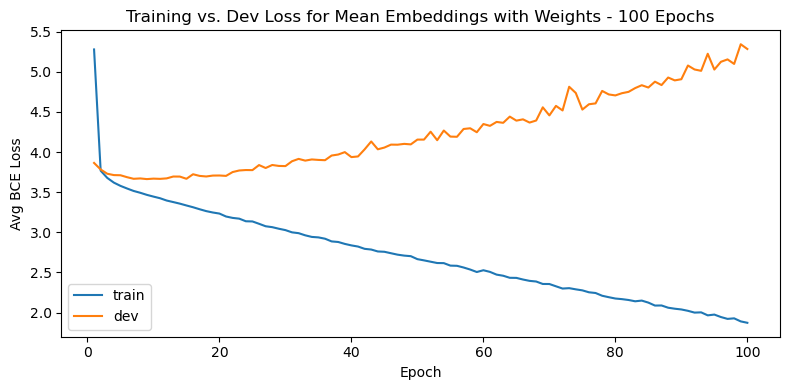

Exact-match accuracy : 0.6121
Hamming accuracy     : 0.9084
Jaccard (samples)    : 0.6311
Micro F1             : 0.6705
Macro F1             : 0.2908

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Nucleoplasm                   0.7550     0.4507
Nucleoli                      0.9669     0.3625
Nuclear Bodies                0.9696     0.0742
Nuclear speckles              0.9750     0.1386
Nuclear membrane              0.9842     0.1744
Fibrillar center              0.9753     0.0490
other                         0.7331     0.4564


In [12]:
# experiment 3: reweighting on mean - 100 epochs
criterion_3 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_3,  experiment_title="Mean Embeddings with Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 4: reweighting on max - 100 epochs
criterion_4 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
reweighting_model_max = run_experiment(x_train_max_tensor, y_train_max_tensor, train_loader_max, x_dev_max_tensor, y_dev_max_tensor, criterion_4, experiment_title="Max Embeddings with Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reweighting_model_max, x_dev_max_tensor, y_dev_max_tensor, locations)

In [ ]:
# experiment 5: no reweighting on mean - 200 epochs
criterion_5 = nn.BCEWithLogitsLoss()
reg_model_mean_200 = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_5, experiment_title="Mean Embeddings no Weights - 200 Epochs", num_epochs=200)
compute_accuracy(reg_model_mean_200, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [13]:
# experiment 6: baseline nonsense data

# make nonsense data by shuffling the labels
y_dev_mean_tensor_shuffled = y_dev_mean_tensor[torch.randperm(y_dev_mean_tensor.size(0))]

# compute accuracy of the original model on the shuffled labels as a sanity check - should be very low
compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor_shuffled, locations)

Exact-match accuracy : 0.3964
Hamming accuracy     : 0.8404
Jaccard (samples)    : 0.4088
Micro F1             : 0.4299
Macro F1             : 0.1348

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Nucleoplasm                   0.5146     0.0046
Nucleoli                      0.9557     0.0240
Nuclear Bodies                0.9734    -0.0045
Nuclear speckles              0.9723    -0.0078
Nuclear membrane              0.9831    -0.0049
Fibrillar center              0.9834     0.0000
other                         0.5000     0.0123


In [ ]:
# experiment 7: investigate focal loss - mean - 100 epochs
import torchvision

def focal_loss(logits, y_train):
    return torchvision.ops.sigmoid_focal_loss(logits, y_train, reduction='mean')
criterion_9 = focal_loss
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_9,  experiment_title="Mean Embeddings with focal loss", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [21]:
# prepare for experiment with ridge regression in the loss function - mean - 100 epochs

# this function is slightly different than the normal train model function because we 
# need to compute the dev loss with the normal criterion, not the regression criterion
# in order to track the actual performance of the model, not just the regression loss
def train_regressed_model(model, loader, criterion_reg, criterion, optimizer, x_dev_tensor, y_dev_tensor, num_epochs, lambda_reg):
    train_loss_lst = []
    dev_loss_lst = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in loader:
            x_batch, y_batch = batch
            optimizer.zero_grad()
            logits = model(x_batch)
            loss_grad = criterion(logits, y_batch) + criterion_reg(model.model[0].weight, model.model[2].weight, lambda_reg)
            loss_grad.backward()
            optimizer.step()
            
            # get the actual loss without regression
            loss = criterion(logits, y_batch)
            train_loss += loss.item() * x_batch.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)

        # evaluate on dev set
        model.eval()
        with torch.no_grad():
            dev_logits = model(x_dev_tensor)
            dev_loss = criterion(dev_logits, y_dev_tensor)
            dev_loss_lst.append(dev_loss.item())
        
        if epoch % 50 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Dev Loss: {dev_loss.item():.4f}")
    print("Training complete.")
    return train_loss_lst, dev_loss_lst

# need a new experiment function too to pass the parameters
def run_experiment_reg(x_train, y_train, train_loader, x_dev, y_dev, criterion_reg, criterion_wo_reg, lambda_reg, experiment_title, num_epochs):
    model = MLP(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst, dev_loss_lst = train_regressed_model(model, train_loader, criterion_reg, criterion_wo_reg, optimizer, x_dev, y_dev, num_epochs, lambda_reg)

    # graph the losses
    plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

In [40]:
# prepare for evaluation with ridge regression in the loss function - mean - 100 epochs

# this function is slightly different than the normal train model function because we 
# need to compute the dev loss with the normal criterion, not the regression criterion
# in order to track the actual performance of the model, not just the regression loss
def train_regressed_model_wo_dev(model, loader, criterion_reg, criterion, optimizer, num_epochs, lambda_reg):
    train_loss_lst = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in loader:
            x_batch, y_batch = batch
            optimizer.zero_grad()
            logits = model(x_batch)
            loss_grad = criterion(logits, y_batch) + criterion_reg(model.model[0].weight, model.model[2].weight, lambda_reg)
            loss_grad.backward()
            optimizer.step()
            
            # get the actual loss without regression
            loss = criterion(logits, y_batch)
            train_loss += loss.item() * x_batch.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)

    print("Training complete.")
    return train_loss_lst

# need a new experiment function too to pass the parameters
def run_experiment_reg_wo_dev(x_train, y_train, train_loader, criterion_reg, criterion_wo_reg, lambda_reg, experiment_title, num_epochs):
    model = MLP(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst = train_regressed_model_wo_dev(model, train_loader, criterion_reg, criterion_wo_reg, optimizer, num_epochs, lambda_reg)

    # graph the losses
    #plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

In [42]:
# evaluation 8 ridge resgression on mean - 100 epochs - TEST SET, no DEV

def ridge_regression(w1, w2, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

# experiment 10: play with tuning the decision boundaries
# train control with no reweighting on mean - 100 epochs
def exp8t(best_cutoffs):
    criterion_reg = ridge_regression
    criterion_wo_reg = nn.BCEWithLogitsLoss()
    title = "Mean Embeddings no Weights, Ridge Regression - 100 Epochs"
    lambda_reg = 0.0001
    reg_model_mean = run_experiment_reg_wo_dev(x_train_mean_tensor_whole, y_train_mean_tensor_whole, train_loader_mean_whole, criterion_reg, criterion_wo_reg, lambda_reg, experiment_title=title, num_epochs=100)
    accs, mccs = compute_accuracy_with_special_cutoffs(reg_model_mean, x_test_mean_tensor, y_test_mean_tensor, locations, best_cutoffs)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp8t(best_cutoffs)
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_8t = np.mean(accs_np, axis=0)
std_accs_8t = np.std(accs_np, ddof=1, axis=0)
mean_mccs_8t = np.mean(mccs_np, axis=0)
std_mccs_8t = np.std(mccs_np, ddof=1, axis=0)

Model 1 started.
Training complete.
Model 1 complete.
Model 2 started.
Training complete.
Model 2 complete.
Model 3 started.
Training complete.
Model 3 complete.
Model 4 started.
Training complete.
Model 4 complete.
Model 5 started.
Training complete.
Model 5 complete.


Model 1 started.
Epoch 1/100, Train Loss: 0.3706, Dev Loss: 0.2883
Epoch 51/100, Train Loss: 0.1396, Dev Loss: 0.1828
Epoch 100/100, Train Loss: 0.1032, Dev Loss: 0.1950
Training complete.


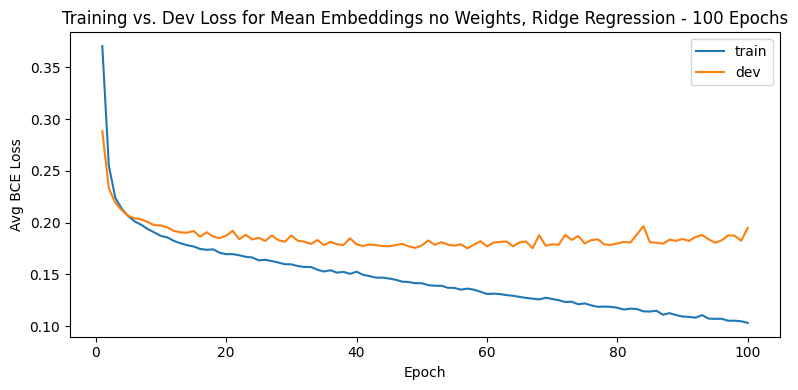

Membrane                 , Best Cutoff:     0.3000, Best MCC:     0.7477
Cytoplasm                , Best Cutoff:     0.4400, Best MCC:     0.6249
Nucleus                  , Best Cutoff:     0.3800, Best MCC:     0.6579
Extracellular            , Best Cutoff:     0.7900, Best MCC:     0.9014
Cell membrane            , Best Cutoff:     0.2400, Best MCC:     0.7098
Mitochondrion            , Best Cutoff:     0.5700, Best MCC:     0.7300
Plastid                  , Best Cutoff:     0.1600, Best MCC:     0.8900
Endoplasmic reticulum    , Best Cutoff:     0.3600, Best MCC:     0.5493
Lysosome/Vacuole         , Best Cutoff:     0.0700, Best MCC:     0.4053
Golgi apparatus          , Best Cutoff:     0.1600, Best MCC:     0.4952
Peroxisome               , Best Cutoff:     0.3200, Best MCC:     0.5082
Model 1 complete.
Model 2 started.
Epoch 1/100, Train Loss: 0.3613, Dev Loss: 0.2753
Epoch 51/100, Train Loss: 0.1351, Dev Loss: 0.1796
Epoch 100/100, Train Loss: 0.0991, Dev Loss: 0.1959
Training 

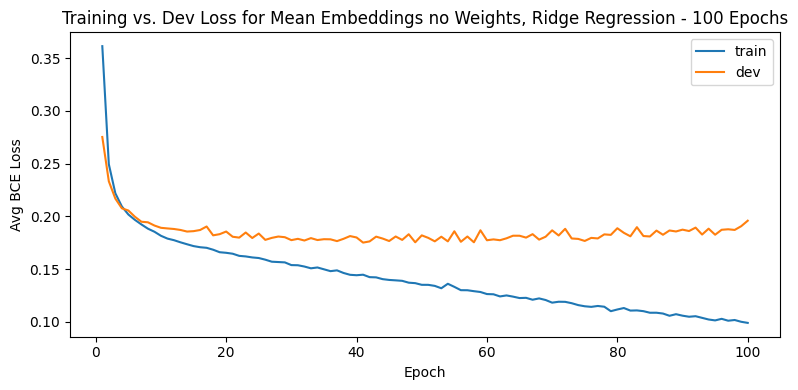

Membrane                 , Best Cutoff:     0.2000, Best MCC:     0.7505
Cytoplasm                , Best Cutoff:     0.6900, Best MCC:     0.6321
Nucleus                  , Best Cutoff:     0.2500, Best MCC:     0.6856
Extracellular            , Best Cutoff:     0.4500, Best MCC:     0.9008
Cell membrane            , Best Cutoff:     0.3700, Best MCC:     0.7005
Mitochondrion            , Best Cutoff:     0.4600, Best MCC:     0.7448
Plastid                  , Best Cutoff:     0.3600, Best MCC:     0.9071
Endoplasmic reticulum    , Best Cutoff:     0.4100, Best MCC:     0.5735
Lysosome/Vacuole         , Best Cutoff:     0.3700, Best MCC:     0.4471
Golgi apparatus          , Best Cutoff:     0.5900, Best MCC:     0.5673
Peroxisome               , Best Cutoff:     0.4700, Best MCC:     0.5082
Model 2 complete.
Model 3 started.
Epoch 1/100, Train Loss: 0.3550, Dev Loss: 0.2706
Epoch 51/100, Train Loss: 0.1310, Dev Loss: 0.1769
Epoch 100/100, Train Loss: 0.0952, Dev Loss: 0.1954
Training 

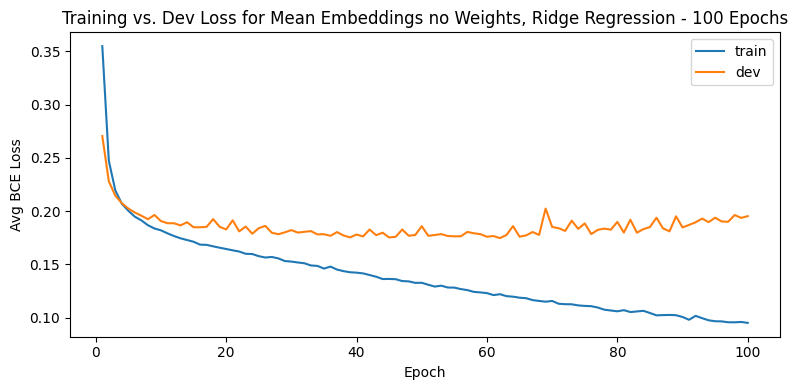

Membrane                 , Best Cutoff:     0.6000, Best MCC:     0.7465
Cytoplasm                , Best Cutoff:     0.2100, Best MCC:     0.6115
Nucleus                  , Best Cutoff:     0.5000, Best MCC:     0.6655
Extracellular            , Best Cutoff:     0.3000, Best MCC:     0.9019
Cell membrane            , Best Cutoff:     0.3600, Best MCC:     0.6902
Mitochondrion            , Best Cutoff:     0.9200, Best MCC:     0.7352
Plastid                  , Best Cutoff:     0.3500, Best MCC:     0.8939
Endoplasmic reticulum    , Best Cutoff:     0.5300, Best MCC:     0.5700
Lysosome/Vacuole         , Best Cutoff:     0.0900, Best MCC:     0.3989
Golgi apparatus          , Best Cutoff:     0.4600, Best MCC:     0.5745
Peroxisome               , Best Cutoff:     0.2100, Best MCC:     0.5082
Model 3 complete.
Model 4 started.
Epoch 1/100, Train Loss: 0.3538, Dev Loss: 0.2687
Epoch 51/100, Train Loss: 0.1328, Dev Loss: 0.1775
Epoch 100/100, Train Loss: 0.0961, Dev Loss: 0.2006
Training 

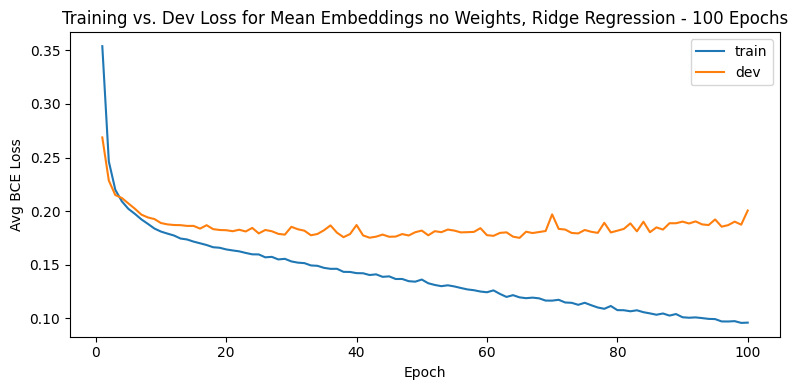

Membrane                 , Best Cutoff:     0.5000, Best MCC:     0.7587
Cytoplasm                , Best Cutoff:     0.1800, Best MCC:     0.6052
Nucleus                  , Best Cutoff:     0.4800, Best MCC:     0.6612
Extracellular            , Best Cutoff:     0.8300, Best MCC:     0.8945
Cell membrane            , Best Cutoff:     0.4800, Best MCC:     0.6894
Mitochondrion            , Best Cutoff:     0.8900, Best MCC:     0.7153
Plastid                  , Best Cutoff:     0.3400, Best MCC:     0.9130
Endoplasmic reticulum    , Best Cutoff:     0.2100, Best MCC:     0.5740
Lysosome/Vacuole         , Best Cutoff:     0.3400, Best MCC:     0.4816
Golgi apparatus          , Best Cutoff:     0.2700, Best MCC:     0.4773
Peroxisome               , Best Cutoff:     0.2100, Best MCC:     0.5021
Model 4 complete.
Model 5 started.
Epoch 1/100, Train Loss: 0.3624, Dev Loss: 0.2693
Epoch 51/100, Train Loss: 0.1366, Dev Loss: 0.1768
Epoch 100/100, Train Loss: 0.0982, Dev Loss: 0.1866
Training 

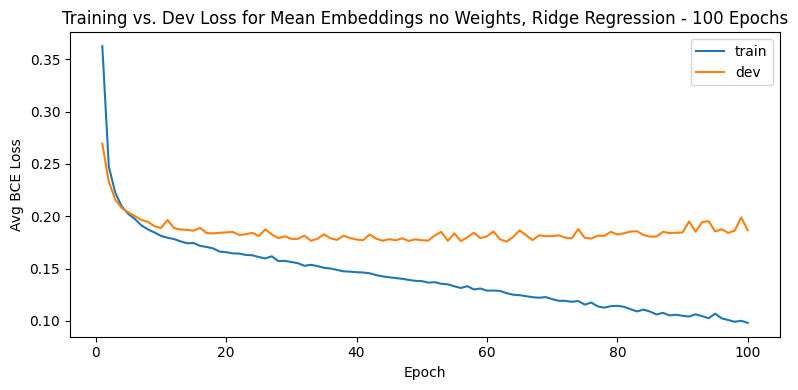

Membrane                 , Best Cutoff:     0.5400, Best MCC:     0.7377
Cytoplasm                , Best Cutoff:     0.4500, Best MCC:     0.6053
Nucleus                  , Best Cutoff:     0.4000, Best MCC:     0.6869
Extracellular            , Best Cutoff:     0.2700, Best MCC:     0.8846
Cell membrane            , Best Cutoff:     0.4100, Best MCC:     0.7055
Mitochondrion            , Best Cutoff:     0.4900, Best MCC:     0.7608
Plastid                  , Best Cutoff:     0.1300, Best MCC:     0.8833
Endoplasmic reticulum    , Best Cutoff:     0.5000, Best MCC:     0.5697
Lysosome/Vacuole         , Best Cutoff:     0.2700, Best MCC:     0.4706
Golgi apparatus          , Best Cutoff:     0.4300, Best MCC:     0.5557
Peroxisome               , Best Cutoff:     0.4000, Best MCC:     0.5149
Model 5 complete.


In [23]:
# experiment 8 ridge resgression on mean - 100 epochs

def ridge_regression(w1, w2, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

# experiment 10: play with tuning the decision boundaries
# train control with no reweighting on mean - 100 epochs
def exp8():
    criterion_reg = ridge_regression
    criterion_wo_reg = nn.BCEWithLogitsLoss()
    title = "Mean Embeddings no Weights, Ridge Regression - 100 Epochs"
    lambda_reg = 0.0001
    reg_model_mean = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg, criterion_wo_reg, lambda_reg, experiment_title=title, num_epochs=100)
    best_cutoffs = compute_optimized_cutoffs(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
    #accs, mccs = compute_accuracy_with_special_cutoffs(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations, best_cutoffs)
    accs, mccs = compute_accuracy_with_special_cutoffs(reg_model_mean, x_test_mean_tensor, y_test_mean_tensor, locations, best_cutoffs)
    return accs, mccs

model_accs = []
model_mccs = []
for i in range(5):
    print(f"Model {i+1} started.")
    acc_mdl, mcc_mdl = exp8()
    model_accs.append(acc_mdl)
    model_mccs.append(mcc_mdl)
    print(f"Model {i+1} complete.")
accs_np = np.array(model_accs)
mccs_np = np.array(model_mccs)
mean_accs_8 = np.mean(accs_np, axis=0)
std_accs_8 = np.std(accs_np, ddof=1, axis=0)
mean_mccs_8 = np.mean(mccs_np, axis=0)
std_mccs_8 = np.std(mccs_np, ddof=1, axis=0)

In [ ]:
# experiment 9 - ridge resgression on mean weighted - 100 epochs

def ridge_regression(w1, w2, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_9 = ridge_regression
criterion_wo_reg_9 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression - 100 Epochs"
regression_model_mean_9 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_9, criterion_wo_reg_9, experiment_title=title, num_epochs=100)
compute_accuracy(regression_model_mean_9, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 10 - ridge resgression on mean weighted - 200 epochs

def ridge_regression(w1, w2, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_10 = ridge_regression
criterion_wo_reg_10 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression - 200 Epochs"
regression_model_mean_10 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_10, criterion_wo_reg_10, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_10, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 11 - ridge resgression on mean weighted - 200 epochs, lambda = 0.01

def ridge_regression(w1, w2, lambda_reg=0.01):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_11 = ridge_regression
criterion_wo_reg_11 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.01 - 200 Epochs"
regression_model_mean_11 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_11, criterion_wo_reg_11, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_11, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 12 - ridge resgression on mean weighted - 100 epochs, lambda = 0.1

def ridge_regression(w1, w2, lambda_reg=0.1):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_12 = ridge_regression
criterion_wo_reg_12 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.1 - 100 Epochs"
regression_model_mean_12 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_12, criterion_wo_reg_12, experiment_title=title, num_epochs=100)
compute_accuracy(regression_model_mean_12, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 13 - ridge resgression on mean weighted - 200 epochs, lambda = 0.1

def ridge_regression(w1, w2, lambda_reg=0.5):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_13 = ridge_regression
criterion_wo_reg_13 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.1 - 200 Epochs"
regression_model_mean_13 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_13, criterion_wo_reg_13, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_13, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [43]:
from great_tables import GT

# visualize each model in a table
metrics_acc = ['Exact Acc.', 'Jaccard', 'Micro F1', 'Macro F1']
#metrics_mcc = ['Nucleoplasm MCC', 'Nucleoli MCC', 'Nuclear Bodies MCC', 'Nuclear speckles MCC',
#                   'Nuclear membrane MCC', 'Fibrillar center MCC']
#metrics_mcc = ['Cytoplasm', 'Nucleus', 'Cell membrane',
#             'Mitochondrion', 'Endoplasmic reticulum', 'Lysosome/Vacuole',
#             'Golgi apparatus', 'Peroxisome']

metrics_mcc = ['Membrane', 'Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane',
             'Mitochondrion', 'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole',
             'Golgi apparatus', 'Peroxisome']

# mean with ROC
mean_accs_1
std_accs_1
mean_mccs_1
std_mccs_1
# mean with ROC with ridge
mean_accs_8
std_accs_8
mean_mccs_8
std_mccs_8

model_names_t1 = ["2H, Mean, Opt. Thresh.", "2H, Mean, Opt. Thresh., Ridge"]
model_names_t3 = ["2H, Mean, Opt. Thresh.", "2H, Mean, Opt. Thresh., Ridge"]
#model_names_t1 = ["1H, Mean, Opt. Thresh.",]
#model_names_t3 = ["1H, Mean, Opt. Thresh.",]

all_means_t1 = np.column_stack([mean_accs_1t, mean_accs_8t])
all_stds_t1 = np.column_stack([std_accs_1t, std_accs_8t])
#all_means_t1 = np.column_stack([mean_accs_1, mean_accs_8])
#all_stds_t1 = np.column_stack([std_accs_1, std_accs_8])

all_means_t3 = np.column_stack([mean_mccs_1t, mean_mccs_8t])
all_stds_t3 = np.column_stack([std_mccs_1t, std_mccs_8t])
#all_means_t3 = np.column_stack([mean_mccs_1, mean_mccs_8])
#all_stds_t3 = np.column_stack([std_mccs_1, std_mccs_8])

#all_means_t1 = np.column_stack([mean_accs_1])
#all_stds_t1 = np.column_stack([std_accs_1])

#all_means_t3 = np.column_stack([mean_mccs_1])
#all_stds_t3 = np.column_stack([std_mccs_1])

rows_t1 = []
rows_t3 = []
for i, metric in enumerate(metrics_acc):
    row_t1 = {"Metric": metric}
    row_t2 = {"Metric": metric}
    row_t3 = {"Metric": metric}
    for j, model_name in enumerate(model_names_t1):
        mean_val = all_means_t1[i,j]
        std_val = all_stds_t1[i,j]
        cell_string = f"{mean_val:.2f} ± {std_val:.2f}"
        row_t1[model_name] = cell_string
    rows_t1.append(row_t1)

for i, metric in enumerate(metrics_mcc):
    row_t3 = {"Metric": metric}
    for j, model_name in enumerate(model_names_t3):
        mean_val = all_means_t3[i,j]
        std_val = all_stds_t3[i,j]
        cell_string = f"{mean_val:.2f} ± {std_val:.2f}"
        row_t3[model_name] = cell_string
    rows_t3.append(row_t3)

df_t1 = pd.DataFrame(rows_t1)
df_t3 = pd.DataFrame(rows_t3)

def style_table(df, model_names, title):
    return (
        GT(df, rowname_col="Metric")
        .tab_header(title=title)
        .fmt_markdown(columns=model_names)
        .tab_options(
            table_font_names="system-ui, -apple-system, sans-serif",
            table_background_color="#ffffff",
            heading_align="left",
            heading_title_font_size="13pt",
            heading_title_font_weight="bold",
            column_labels_background_color="#f8fafc",
            column_labels_font_weight="600",
            column_labels_border_top_style="solid",
            column_labels_border_top_width="2px",
            column_labels_border_top_color="#cbd5e1",
            column_labels_border_bottom_style="solid",
            column_labels_border_bottom_width="2px",
            column_labels_border_bottom_color="#cbd5e1",
            row_group_background_color="#f1f5f9",
            row_group_font_weight="bold",
            row_group_font_size="10pt",
            table_border_bottom_style="solid",
            table_border_bottom_width="2px",
            table_border_bottom_color="#94a3b8",
            data_row_padding="7px"
        )
    )

gt_table_1 = style_table(df_t1, model_names_t1, "Table 1: ROC, 2 Hidden, Accs")
gt_table_3 = style_table(df_t3, model_names_t3, "Table 2: ROC, 2 Hidden, MCCs")

# save them
gt_table_1.save("table_1_TEST_wholeTrain_2h_mlp.pdf")
gt_table_3.save("table_2_TEST_wholeTrain_2h_mlp.pdf")

GT(_tbl_data=                   Metric 2H, Mean, Opt. Thresh. 2H, Mean, Opt. Thresh., Ridge
0                Membrane            0.00 ± 0.00                   0.00 ± 0.00
1               Cytoplasm            0.20 ± 0.01                   0.22 ± 0.02
2                 Nucleus            0.34 ± 0.01                   0.38 ± 0.02
3           Extracellular            0.00 ± 0.00                   0.00 ± 0.00
4           Cell membrane            0.28 ± 0.02                   0.29 ± 0.01
5           Mitochondrion            0.48 ± 0.02                   0.53 ± 0.02
6                 Plastid            0.00 ± 0.00                   0.00 ± 0.00
7   Endoplasmic reticulum            0.13 ± 0.02                   0.11 ± 0.06
8        Lysosome/Vacuole           -0.00 ± 0.00                   0.02 ± 0.06
9         Golgi apparatus            0.20 ± 0.02                   0.19 ± 0.08
10             Peroxisome            0.11 ± 0.24                   0.00 ± 0.00, _body=<great_tables._gt_data.Body object at 0x13e61ea50>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.stub: 2>, column_label='Metric', column_align='left', column_width=None), ColInfo(var='2H, Mean, Opt. Thresh.', type=<ColInfoTypeEnum.default: 1>, column_label='2H, Mean, Opt. Thresh.', column_align='left', column_width=None), ColInfo(var='2H, Mean, Opt. Thresh., Ridge', type=<ColInfoTypeEnum.default: 1>, column_label='2H, Mean, Opt. Thresh., Ridge', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x13e68e470>, _spanners=Spanners([]), _heading=Heading(title='Table 2: ROC, 2 Hidden, MCCs', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x151a9fad0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x31fe46510>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x13e68e580>, _formats=[<great_tables._gt_data.FormatInfo object at 0x13e68e250>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#ffffff'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['system-ui, -apple-system, sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=Fal

Epoch 1/100, Train Loss: 0.3598, Dev Loss: 0.2811
Epoch 11/100, Train Loss: 0.1789, Dev Loss: 0.1889
Epoch 21/100, Train Loss: 0.1614, Dev Loss: 0.1816
Epoch 31/100, Train Loss: 0.1498, Dev Loss: 0.1777
Epoch 41/100, Train Loss: 0.1399, Dev Loss: 0.1761
Epoch 51/100, Train Loss: 0.1317, Dev Loss: 0.1764
Epoch 61/100, Train Loss: 0.1250, Dev Loss: 0.1775
Epoch 71/100, Train Loss: 0.1190, Dev Loss: 0.1795
Epoch 81/100, Train Loss: 0.1132, Dev Loss: 0.1813
Epoch 91/100, Train Loss: 0.1077, Dev Loss: 0.1837
Epoch 100/100, Train Loss: 0.1039, Dev Loss: 0.1899
Training complete.


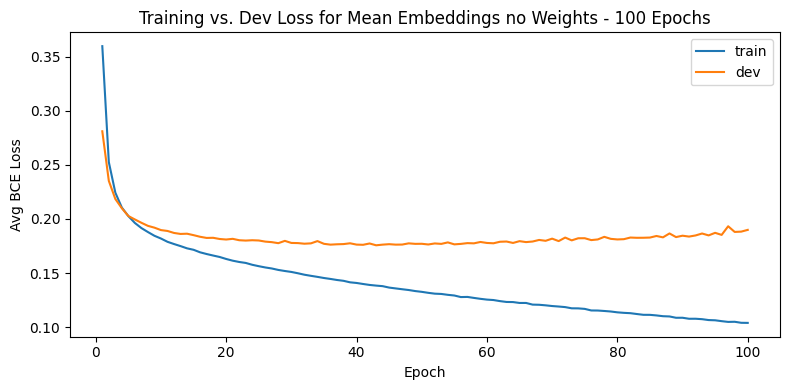

Membrane                 , Best Cutoff:     0.3500, Best MCC:     0.7383
Cytoplasm                , Best Cutoff:     0.4500, Best MCC:     0.6312
Nucleus                  , Best Cutoff:     0.6800, Best MCC:     0.6620
Extracellular            , Best Cutoff:     0.4300, Best MCC:     0.9050
Cell membrane            , Best Cutoff:     0.5600, Best MCC:     0.6830
Mitochondrion            , Best Cutoff:     0.4900, Best MCC:     0.7446
Plastid                  , Best Cutoff:     0.1900, Best MCC:     0.9022
Endoplasmic reticulum    , Best Cutoff:     0.4400, Best MCC:     0.5853
Lysosome/Vacuole         , Best Cutoff:     0.1700, Best MCC:     0.4292
Golgi apparatus          , Best Cutoff:     0.5000, Best MCC:     0.5729
Peroxisome               , Best Cutoff:     0.4600, Best MCC:     0.5455
Exact-match accuracy : 0.5237
Hamming accuracy     : 0.9332
Jaccard (samples)    : 0.7076
Micro F1             : 0.7641
Macro F1             : 0.7109

Per-class metrics:
Location                   

In [ ]:
# experiment 14: control with no reweighting on mean - 100 epochs - MCC optimization
criterion_1 = nn.BCEWithLogitsLoss()
reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
cutoffs = compute_optimized_cutoffs(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
compute_accuracy_with_special_cutoffs(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations, cutoffs)